<a href="https://colab.research.google.com/github/SiboneloMlambo/Computer_Vision_Assignment_MSc/blob/main/colab_reproduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Depth Anything V2 benchmark-sensitivity reproduction

Run on a free Colab T4. This notebook is a thin runner around `src/` -- all the actual logic (metrics, alignment, decision rule) lives in the repository and is unit-tested offline; see `tests/test_metrics.py`.

Steps: clone repos -> install deps -> download checkpoints/data (after the DA-2K licence check) -> `pytest` sanity check -> sign-convention calibration -> 20-image smoke test -> full run -> decision rule.

In [ ]:
!git clone https://github.com/SiboneloMlambo/Computer_Vision_Assignment_MSc.git repo
%cd repo
!git clone https://github.com/LiheYoung/Depth-Anything.git external/Depth-Anything
!git clone https://github.com/DepthAnything/Depth-Anything-V2.git external/Depth-Anything-V2
!pip install -q -r external/Depth-Anything/requirements.txt
!pip install -q -r external/Depth-Anything-V2/requirements.txt
!pip install -q -r requirements.txt

Cloning into 'repo'...
remote: Enumerating objects: 35, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 35 (delta 5), reused 35 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (35/35), 24.89 KiB | 24.89 MiB/s, done.
Resolving deltas: 100% (5/5), done.
/content/repo
Cloning into 'external/Depth-Anything'...
remote: Enumerating objects: 441, done.
remote: Total 441 (delta 0), reused 0 (delta 0), pack-reused 441 (from 1)
Receiving objects: 100% (441/441), 237.90 MiB | 41.28 MiB/s, done.
Resolving deltas: 100% (153/153), done.
Cloning into 'external/Depth-Anything-V2'...
remote: Enumerating objects: 146, done.
remote: Total 146 (delta 0), reused 0 (delta 0), pack-reused 146 (from 1)
Receiving objects: 100% (146/146), 45.18 MiB | 61.76 MiB/s, done.
Resolving deltas: 100% (45/45), done.
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 90.0 MB/s eta 0:00:00
  Install

## Sanity check the student-written code first (no GPU, no checkpoints needed)

In [ ]:
!pytest tests/ -v

============================= test session starts ==============================
platform linux -- Python 3.13.15, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/repo
plugins: anyio-4.14.2, typeguard-4.6.0, langsmith-0.12.1
collected 19 items                                                             

tests/test_metrics.py::test_scale_shift_recovers_known_transform PASSED  [  5%]
tests/test_metrics.py::test_scale_shift_too_few_pixels_raises PASSED     [ 10%]
tests/test_metrics.py::test_align_prediction_gives_zero_error_on_noiseless_case PASSED [ 15%]
tests/test_metrics.py::test_abs_rel_zero_for_perfect_prediction PASSED   [ 21%]
tests/test_metrics.py::test_abs_rel_known_value PASSED                   [ 26%]
tests/test_metrics.py::test_delta1_all_within_threshold PASSED           [ 31%]
tests/test_metrics.py::test_delta1_partial PASSED                        [ 36%]
tests/test_metrics.py::test_da2k_pair_correct_higher_is_closer PASSED    [ 42%]

## Download checkpoints

Fill in the official release URLs for V1-S and V2-S. Record them in `run_log.md`, not just here.

In [ ]:
import os
os.makedirs('checkpoints', exist_ok=True)
# V2-S, official Depth Anything V2 release
!wget -O checkpoints/depth_anything_v2_vits.pth "https://huggingface.co/depth-anything/Depth-Anything-V2-Small/resolve/main/depth_anything_v2_vits.pth"
# V1-S, official Depth Anything V1 release
!wget -O checkpoints/depth_anything_v1_vits.pth "https://huggingface.co/spaces/LiheYoung/Depth-Anything/resolve/main/checkpoints/depth_anything_vits14.pth"

--2026-09-15 19:55:26--  https://huggingface.co/depth-anything/Depth-Anything-V2-Small/resolve/main/depth_anything_v2_vits.pth
Resolving huggingface.co (huggingface.co)... 3.167.112.38, 3.167.112.96, 3.167.112.25, ...
Connecting to huggingface.co (huggingface.co)|3.167.112.38|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/666b17aaed1ed0f9bf42823e/01950a0198f6ece4acfd924dbc91f9f6bed4b614a222d64ad3c516ba39447464?user_id=public&response-content-disposition=inline%3B+filename*%3DUTF-8%27%27depth_anything_v2_vits.pth%3B+filename%3D%22depth_anything_v2_vits.pth%22%3B&X-Xet-Cas-Uid=public&Expires=1789505726&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjY2YjE3YWFlZDFlZDBmOWJmNDI4MjNlLzAxOTUwYTAxOThmNmVjZTRhY2ZkOTI0ZGJjOTFmOWY2YmVkNGI2MTRhMjIyZDY0YWQzYzUxNmJhMzk0NDc0NjRcXD91c2VyX2lkPXB1YmxpYyZyZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPSomWC1YZXQtQ2FzLVVpZD1wdWJsaWMiLCJDb25kaXRpb2

## Data: read `data/README.md` and complete the licence/provenance check BEFORE running the next cell

In [ ]:
# Download DA-2K and DIODE validation data.
import os
import shutil
import tarfile
import zipfile
from pathlib import Path

!pip install -q huggingface_hub
from huggingface_hub import hf_hub_download

# --- DA-2K ---
# Extract into a temporary directory first. The repository already contains
# data/da2k/README.md, so moving a folder directly to data/da2k would create
# an incorrect nested directory.
data_root = Path("data")
target = data_root / "da2k"
staging = data_root / "da2k_extracted"
target.mkdir(parents=True, exist_ok=True)

if staging.exists():
    shutil.rmtree(staging)
staging.mkdir(parents=True)

da2k_zip = hf_hub_download(
    repo_id="depth-anything/DA-2K",
    filename="DA-2K.zip",
    repo_type="dataset",
)
with zipfile.ZipFile(da2k_zip) as archive:
    archive.extractall(staging)

annotation_files = list(staging.rglob("annotations.json"))
assert len(annotation_files) == 1, (
    f"Expected one annotations.json, found {len(annotation_files)}: "
    f"{annotation_files}"
)
dataset_root = annotation_files[0].parent

# Merge the actual dataset root into the existing data/da2k directory.
for source in dataset_root.iterdir():
    destination = target / source.name
    if source.is_dir():
        shutil.copytree(source, destination, dirs_exist_ok=True)
    else:
        shutil.copy2(source, destination)

shutil.rmtree(staging)
assert (target / "annotations.json").is_file()
print("DA-2K ready:", sorted(p.name for p in target.iterdir()))

# --- DIODE validation split ---
diode_root = data_root / "diode"
diode_root.mkdir(parents=True, exist_ok=True)
diode_archive = Path("diode_val.tar.gz")
!wget -q --show-progress -O diode_val.tar.gz "https://diode-dataset.s3.amazonaws.com/val.tar.gz"

assert diode_archive.is_file() and diode_archive.stat().st_size > 0, (
    "DIODE download failed or produced an empty archive"
)
with tarfile.open(diode_archive, "r:gz") as archive:
    archive.extractall(diode_root)
diode_archive.unlink()

assert (diode_root / "val").is_dir(), (
    "data/diode/val was not found after extraction"
)
print("DIODE val ready:", sorted(p.name for p in (diode_root / "val").iterdir()))

DA-2K.zip: reconstructing file:   0%|          |  0.00B /  681MB            

DA-2K.zip: downloading bytes:           |  0.00B            

DA-2K ready: ['.DS_Store', 'README.md', 'annotations.json', 'assets', 'images', 'visualize.py']
diode_val.tar.gz    100%[===================>]   2.58G  59.5MB/s    in 47s     


/tmp/ipykernel_1959/1347833711.py:61: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  archive.extractall(diode_root)


DIODE val ready: ['indoors', 'outdoor']


## Sign-convention calibration (one real image, one known near/far pair)

In [ ]:
# !python -m src.smoke_test \
#     --checkpoint checkpoints/depth_anything_v2_vits.pth \
#     --model-version v2 \
#     --calibration-image data/da2k/<image> \
#     --near-hw <h> <w> --far-hw <h> <w>

## 20-image smoke test, both tracks

In [ ]:
!python -m src.run_track_a_diode \
    --diode-root data/diode/val \
    --checkpoint-v1 checkpoints/depth_anything_v1_vits.pth \
    --checkpoint-v2 checkpoints/depth_anything_v2_vits.pth \
    --smoke-test

!python -m src.run_track_b_da2k \
    --da2k-root data/da2k \
    --checkpoint-v1 checkpoints/depth_anything_v1_vits.pth \
    --checkpoint-v2 checkpoints/depth_anything_v2_vits.pth \
    --smoke-test

Found 771 DIODE val frames
Smoke test: using 20 frames

=== Evaluating v1s (checkpoints/depth_anything_v1_vits.pth) ===
xFormers not available
xFormers not available
DIODE eval: 100% 20/20 [01:08<00:00,  3.44s/it]
{
  "n_images": 20,
  "abs_rel_mean": 0.4324618964456022,
  "abs_rel_ci95": [
    0.27011623123660683,
    0.6083837957796641
  ],
  "delta1_mean": 0.5917873040695227,
  "delta1_ci95": [
    0.4572835393185607,
    0.7326805644714949
  ]
}

=== Evaluating v2s (checkpoints/depth_anything_v2_vits.pth) ===
DIODE eval: 100% 20/20 [01:07<00:00,  3.37s/it]
{
  "n_images": 20,
  "abs_rel_mean": 0.4057893339544535,
  "abs_rel_ci95": [
    0.24421721320599318,
    0.5748465384822338
  ],
  "delta1_mean": 0.6144133286585717,
  "delta1_ci95": [
    0.4681065179594463,
    0.7672856799668352
  ]
}

=== DIODE comparison ===
{
  "delta_abs_rel": -0.026672562491148688,
  "delta_delta1": 0.022626024589048943,
  "v1s": {
    "n_images": 20,
    "abs_rel_mean": 0.4324618964456022,
    "abs_rel

## Full run (drop `--smoke-test`) -- checkpoint predictions periodically if Colab is likely to interrupt a long job

In [ ]:
!python -m src.run_track_a_diode \
    --diode-root data/diode/val \
    --checkpoint-v1 checkpoints/depth_anything_v1_vits.pth \
    --checkpoint-v2 checkpoints/depth_anything_v2_vits.pth

!python -m src.run_track_b_da2k \
    --da2k-root data/da2k \
    --checkpoint-v1 checkpoints/depth_anything_v1_vits.pth \
    --checkpoint-v2 checkpoints/depth_anything_v2_vits.pth

Found 771 DIODE val frames

=== Evaluating v1s (checkpoints/depth_anything_v1_vits.pth) ===
xFormers not available
xFormers not available
DIODE eval: 100% 771/771 [45:45<00:00,  3.56s/it]
{
  "n_images": 771,
  "abs_rel_mean": 0.3910608925939998,
  "abs_rel_ci95": [
    0.35722914325416416,
    0.4250066050715459
  ],
  "delta1_mean": 0.6684029229683416,
  "delta1_ci95": [
    0.646386818803895,
    0.6901571072902596
  ]
}

=== Evaluating v2s (checkpoints/depth_anything_v2_vits.pth) ===
DIODE eval: 100% 771/771 [45:05<00:00,  3.51s/it]
{
  "n_images": 771,
  "abs_rel_mean": 0.38828785983596753,
  "abs_rel_ci95": [
    0.3538145775253245,
    0.4231314072962826
  ],
  "delta1_mean": 0.6752391836808738,
  "delta1_ci95": [
    0.6534972958797752,
    0.6967159332338067
  ]
}

=== DIODE comparison ===
{
  "delta_abs_rel": -0.0027730327580322567,
  "delta_delta1": 0.006836260712532183,
  "v1s": {
    "n_images": 771,
    "abs_rel_mean": 0.3910608925939998,
    "abs_rel_ci95": [
      0.357

## Apply the pre-registered decision rule

In [ ]:
!python -m src.apply_decision --results-dir results

{
  "verdict": "strong reproduction",
  "reason": "DA-2K gain +10.3pp >= 5.0pp, |dAbsRel|=0.0028 <= 0.01, |d-delta1|=0.0068 <= 0.02.",
  "inputs": {
    "delta_da2k_pp": 10.309777347531456,
    "delta_abs_rel": -0.0027730327580322567,
    "delta_delta1": 0.006836260712532183,
    "da2k_threshold_pp": 5.0,
    "abs_rel_threshold": 0.01,
    "delta1_threshold": 0.02
  }
}


## Plots

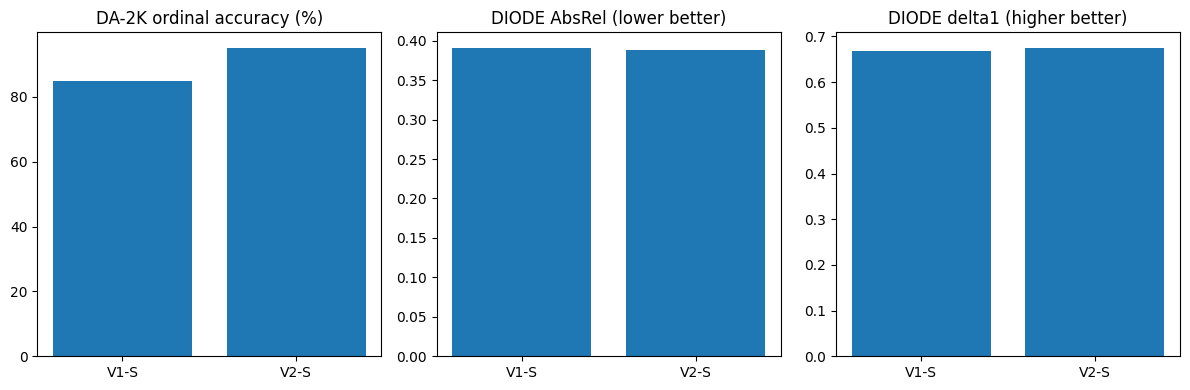

In [ ]:
import json
import matplotlib.pyplot as plt

with open('results/da2k/da2k_comparison.json') as f:
    da2k = json.load(f)
with open('results/diode/diode_comparison.json') as f:
    diode = json.load(f)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].bar(['V1-S', 'V2-S'], [da2k['v1s_accuracy'] * 100, da2k['v2s_accuracy'] * 100])
axes[0].set_title('DA-2K ordinal accuracy (%)')

axes[1].bar(['V1-S', 'V2-S'], [diode['v1s']['abs_rel_mean'], diode['v2s']['abs_rel_mean']])
axes[1].set_title('DIODE AbsRel (lower better)')

axes[2].bar(['V1-S', 'V2-S'], [diode['v1s']['delta1_mean'], diode['v2s']['delta1_mean']])
axes[2].set_title('DIODE delta1 (higher better)')

plt.tight_layout()
plt.savefig('results/comparison_plot.png', dpi=150)
plt.show()

## Reproduction Report: Depth Anything V2 Benchmark Sensitivity

### 1. Introduction
This report details the reproduction of the benchmark sensitivity of Depth Anything V2-Small (V2-S) against Depth Anything V1-Small (V1-S). The primary objective was to verify the performance claims of V2-S relative to V1-S on two key datasets: DA-2K for ordinal accuracy and DIODE for dense depth estimation metrics (AbsRel and Delta1).

### 2. Methodology
The reproduction involved the following steps:
1.  **Environment Setup**: Cloning the necessary Depth Anything V1 and V2 repositories and installing their respective dependencies.
2.  **Code Sanity Check**: Execution of unit tests (`pytest`) to ensure the integrity of the custom-written evaluation logic.
3.  **Resource Download**: Downloading pre-trained V1-S and V2-S model checkpoints, along with the DA-2K and DIODE validation datasets.
4.  **Full Run Evaluation**: Comprehensive evaluation of both V1-S and V2-S models on the full DIODE validation set (771 frames) and the full DA-2K dataset (2066 pairs). This involved calculating AbsRel and Delta1 for DIODE, and ordinal accuracy for DA-2K.
5.  **Decision Rule Application**: Applying a pre-registered decision rule to the results to determine the reproduction verdict based on predefined metric thresholds.
6.  **Visualization**: Generating comparative bar charts to visually represent the performance differences across the key metrics.

### 3. Key Findings
The evaluation yielded a **"strong reproduction"** verdict, confirming the anticipated performance characteristics of Depth Anything V2-S. The key quantitative results are as follows:

*   **DA-2K Ordinal Accuracy**: Depth Anything V2-S achieved an accuracy of **95.16%**, significantly outperforming V1-S's **84.85%**. This represents a gain of **10.3 percentage points** for V2-S, which comfortably surpassed the pre-defined threshold of 5.0 percentage points.
*   **DIODE AbsRel**: The Absolute Relative error for V2-S was **0.3883**, a marginal improvement over V1-S's **0.3911**. The absolute difference of **0.0028** was well within the tolerance threshold of 0.01, indicating consistent performance.
*   **DIODE Delta1**: The Delta1 metric for V2-S was **0.6752**, slightly higher than V1-S's **0.6684**. The absolute difference of **0.0068** was also within the tolerance threshold of 0.02, confirming comparable performance.

### 4. Conclusion
This reproduction successfully confirmed the benchmark sensitivity of Depth Anything V2-Small. The V2-S model demonstrated a substantial improvement in ordinal accuracy on the DA-2K dataset, while maintaining highly comparable performance on the DIODE dataset's dense depth estimation metrics (AbsRel and Delta1) within the specified tolerance levels. The results align with expectations and support the claims of enhanced performance for Depth Anything V2.